# MIR: regridding octahedral GRIB fieldlist

#### Regridding

In [1]:
import earthkit.data as ekd

import earthkit.geo as ekg

# Get octahedral reduced Gaussian GRIB data containing two fields.
ds = ekd.from_source("sample", "O32_t2.grib2").to_fieldlist()

# the target grid is a global 5x5 degree regular latitude-longitude grid
out_grid = {"grid": [5, 5]}

# perform interpolation for each field and add results
# to a new fieldlist stored in memory
r = ekg.regrid(ds, out_grid=out_grid, interpolation="linear")

O32_t2.grib2:   0%|          | 0.00/31.4k [00:00<?, ?B/s]

Cache file /tmp/cache/mir/weights/18/linear/R32-98df937a38e9495da1d994b0eeb43e8b-87.8638:0:-87.8638:357.5/LL-5x5-90:0:-90:355-0a5644c49e38d4e140050e3165e32615.mat does not exist
Creating cache file /tmp/cache/mir/weights/18/linear/R32-98df937a38e9495da1d994b0eeb43e8b-87.8638:0:-87.8638:357.5/LL-5x5-90:0:-90:355-0a5644c49e38d4e140050e3165e32615.mat
CacheManager creating file /tmp/cache/mir/weights/18/linear/R32-98df937a38e9495da1d994b0eeb43e8b-87.8638:0:-87.8638:357.5/LL-5x5-90:0:-90:355-0a5644c49e38d4e140050e3165e32615.mat


#### Plotting the results

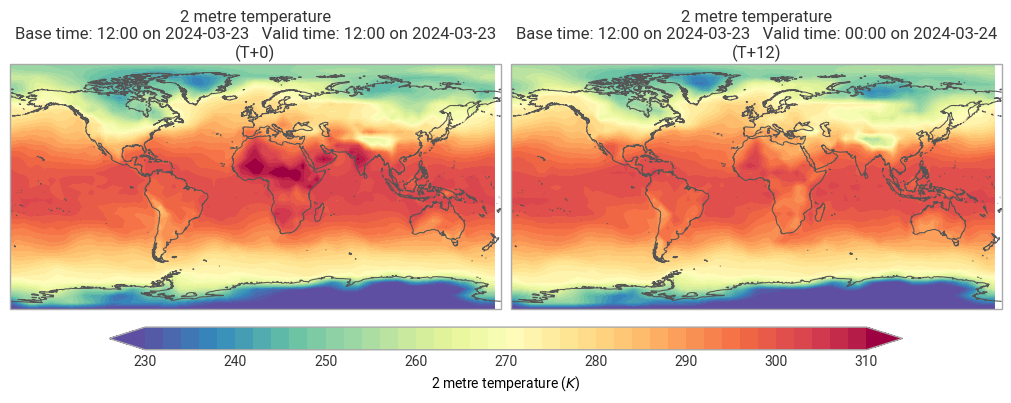

In [2]:
import earthkit.plots as ekp

ekp.quickplot(r)

#### Converting the results to xarray

In [3]:
r.to_xarray()

<xarray.Dataset> Size: 44kB
Dimensions:    (step: 2, latitude: 37, longitude: 72)
Coordinates:
  * step       (step) timedelta64[ns] 16B 00:00:00 12:00:00
  * latitude   (latitude) float64 296B 90.0 85.0 80.0 75.0 ... -80.0 -85.0 -90.0
  * longitude  (longitude) float64 576B 0.0 5.0 10.0 15.0 ... 345.0 350.0 355.0
Data variables:
    2t         (step, latitude, longitude) float64 43kB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

#### Writing the results to disk

Write the resulting fieldlist to disk:

In [4]:
out_file = "_res_O32_to_5x5.grib"
r.to_target("file", out_file)